# Question 1: b (exponential)

# Question 2: a (gamma)

# Problem 1: Are the Two Methods Equivalent?

We want to check whether two different random experiments generate the **same probability distribution**.

The two experiments are:

1. Rolling **two fair six-sided dice**
2. Throwing **ten independent binary lots**, counting the marked sides (1), and then **adding 2**

Both experiments produce values from **2 to 12**, but this does not automatically mean they are equivalent.

---

## What does “equivalent” mean?

Two random experiments are equivalent **only if**:

- They produce the same possible values  
- They assign the **same probability** to each value

Having the same values is not enough.

---

## Method 1: Two Six-Sided Dice

Each die takes values:

$$
\{1, 2, 3, 4, 5, 6\}
$$

The result is the **sum** of the two dice.

---

### Sample space

There are:

$$
6 \times 6 = 36
$$

equally likely outcomes.  
Each outcome has probability:

$$
\frac{1}{36}
$$

---

### Distribution of the sum

Let $X$ be the sum of the two dice.

Possible values:

$$
X = 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12
$$

Number of ways to obtain some sums:

- $X = 2$: only $(1,1)$ → 1 way  
- $X = 7$: six combinations → 6 ways  
- $X = 12$: only $(6,6)$ → 1 way  

Therefore:

- $P(X = 2) = \frac{1}{36}$
- $P(X = 7) = \frac{6}{36}$
- $P(X = 12) = \frac{1}{36}$

The probabilities increase linearly up to 7 and then decrease symmetrically.

---

## Method 2: Ten Binary Lots

Each binary lot has two equally likely outcomes:

- 0 (unmarked)
- 1 (marked)

Each lot is a Bernoulli random variable with probability 0.5.

---

### Distribution before adding 2

Let:

$$
Y = B_1 + B_2 + \dots + B_{10}
$$

Then:

- $Y$ counts the number of marked sides
- Possible values:

$$
Y = 0, 1, 2, \dots, 10
$$

$Y$ follows a binomial distribution with parameters $n = 10$ and $p = 0.5$:

$$
P(Y = k) = \binom{10}{k} \left(\frac{1}{2}\right)^{10}
$$

This distribution is symmetric and centered at $k = 5$.

---

### After adding 2

Define:

$$
Z = Y + 2
$$

Then the possible values are:

$$
Z = 2, 3, 4, \dots, 12
$$

The set of values now matches the dice experiment.

---

## Comparing the two experiments

Let us compare a few probabilities:

| Value | Two dice | Binary lots (+2) |
|------|---------|------------------|
| 2 | $1/36$ | $1/1024$ |
| 7 | $6/36$ | $252/1024$ |
| 12 | $1/36$ | $1/1024$ |

The probabilities are clearly different.

---

## Why the methods are not equivalent

- Two dice produce a **triangular distribution**
- Ten binary lots produce a **binomial distribution**

Even though both experiments produce values from 2 to 12, they assign **different probabilities** to those values.

---

## Final conclusion

$$
\text{Same outcomes} \neq \text{same distribution}
$$

**The two methods are not equivalent.**

# Problem 2: Crown and Anchor

In [2]:
import pymc as pm

with pm.Model() as model:
	X = pm.Binomial('X', n=3, p=1/6)

# Problem 3: Craps

In [3]:
point = 5
with pm.Model() as model:
    # Roll two dice
    d1 = pm.DiscreteUniform('d1', lower=1, upper=6)	
    d2 = pm.DiscreteUniform('d2', lower=1, upper=6)
    # Calculate the sum of the dice
    sum_dice = pm.Deterministic('sum_dice', d1 + d2)
    # If sum_dice equals point, return 1 (win)
	# If sum_dice equals 7, return -1 (lose)
	# Otherwise, return 0 (continue)
    res = pm.math.switch(pm.math.eq(sum_dice, point), 1, pm.math.switch(pm.math.eq(sum_dice, 7), -1, 0))
    
# Simulate 1000 games
results = pm.draw(res, draws=1000)
# Calculate probabilities
num_point_wins = (results == 1).sum()
num_seven_losses = (results == -1).sum()
# The probability of winning by rolling the point before a 7
point_win_prob = num_point_wins / (num_point_wins + num_seven_losses)
print(f"Probability of winning by rolling the point {point} before a 7: {point_win_prob:.4f}")

Probability of winning by rolling the point 5 before a 7: 0.4878


# Problem 4: BF

Multiprocess sampling (4 chains in 4 jobs)
Metropolis: [T]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 16 seconds.


<Axes: title={'center': 'T'}>

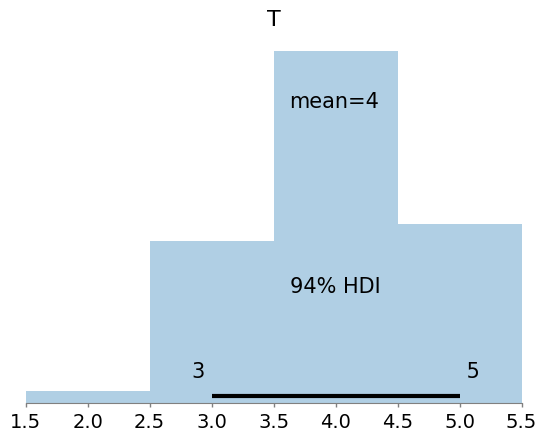

In [7]:
import pymc as pm
import numpy as np
import arviz as az

# observed outcomes: L=0, E=1, G=2
obs = np.array([2, 2, 0, 1, 0, 0, 0, 1, 2, 0])

with pm.Model() as model:

    # Prior: target T is a fair die (values 1..6)
    T = pm.DiscreteUniform("T", lower=1, upper=6)

    # Likelihood
    R = pm.Categorical("R", p=[(T - 1) / 6, 1 / 6, (6 - T) / 6], observed=obs)

    trace = pm.sample(2000)

# Posterior visualization
az.plot_posterior(trace, var_names=["T"])